In [20]:
import itertools
import pandas as pd
import numpy as np
import re
import os
from tqdm import tqdm

# Drawing the embeddings
import matplotlib.pyplot as plt

# Deep learning: 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from scipy import sparse

# Custom functions
from utility import text_preprocessing, create_unique_word_dict

In [21]:
# Reading the text from the input folder
texts = pd.read_csv('input/sample.csv')
texts = [x for x in texts['text']]

In [22]:
# Defining the window for context
window = 2

# Creating a placeholder for the scanning of the word list
word_lists = []
all_text = []

for text in texts:

    # Cleaning the text
    text = text_preprocessing(text)

    # Appending to the all text list
    all_text += text 

    # Creating a context dictionary
    for i, word in enumerate(text):
        for w in range(window):
            # Getting the context that is ahead by *window* words
            if i + 1 + w < len(text): 
                word_lists.append([word] + [text[(i + 1 + w)]])
            # Getting the context that is behind by *window* words    
            if i - w - 1 >= 0:
                word_lists.append([word] + [text[(i - w - 1)]])

unique_word_dict = create_unique_word_dict(all_text)

# Defining the number of features (unique words)
n_words = len(unique_word_dict)

# Getting all the unique words 
words = list(unique_word_dict.keys())

In [23]:
# Creating the X and Y matrices using one hot encoding
X = []
Y = []

for i, word_list in tqdm(enumerate(word_lists)):
    # Getting the indices
    main_word_index = unique_word_dict.get(word_list[0])
    context_word_index = unique_word_dict.get(word_list[1])

    # Creating the placeholders   
    X_row = np.zeros(n_words)
    Y_row = np.zeros(n_words)

    # One hot encoding the main word
    X_row[main_word_index] = 1

    # One hot encoding the Y matrix words 
    Y_row[context_word_index] = 1

    # Appending to the main matrices
    X.append(X_row)
    Y.append(Y_row)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

84it [00:00, 325319.98it/s]


In [24]:
# Defining the size of the embedding
embed_size = 2

# Defining the neural network
inp = Input(shape=(X.shape[1],))
x = Dense(units=embed_size, activation='linear')(inp)
x = Dense(units=Y.shape[1], activation='softmax')(x)
model = Model(inputs=inp, outputs=x)
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam')

# Optimizing the network weights
model.fit(
    x=X, 
    y=Y, 
    batch_size=256,
    epochs=1000
    )

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 3.0537
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.0526
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.0516
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.0505
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.0495
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.0484
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.0474
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.0463
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.0453
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0442
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0432
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0421
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.0411
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.0401
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.0390
Epo

In [25]:
unique_word_dict

{'beautiful': 0,
 'boy': 1,
 'can': 2,
 'children': 3,
 'daughter': 4,
 'family': 5,
 'future': 6,
 'king': 7,
 'man': 8,
 'now': 9,
 'only': 10,
 'prince': 11,
 'princess': 12,
 'queen': 13,
 'realm': 14,
 'royal': 15,
 'rule': 16,
 'son': 17,
 'strong': 18,
 'their': 19,
 'woman': 20}

In [26]:
# Obtaining the weights from the neural network. 
# These are the so called word embeddings

# The input layer 
weights = model.get_weights()[0]

# Creating a dictionary to store the embeddings in. The key is a unique word and 
# the value is the numeric vector
embedding_dict = {}
for word in words: 
    embedding_dict.update({
        word: weights[unique_word_dict.get(word)]
        })

In [27]:
weights.shape

(21, 2)

In [28]:
embedding_dict

{'beautiful': array([-1.0762838, -1.5971307], dtype=float32),
 'boy': array([0.92710775, 0.5374754 ], dtype=float32),
 'can': array([0.8101938, 0.2967478], dtype=float32),
 'children': array([-0.81370836,  0.14572755], dtype=float32),
 'daughter': array([-1.0175549, -1.55282  ], dtype=float32),
 'family': array([-0.60495245,  0.8435519 ], dtype=float32),
 'future': array([-0.33812252,  1.364955  ], dtype=float32),
 'king': array([-1.34405   ,  0.47642112], dtype=float32),
 'man': array([1.1036779 , 0.71954495], dtype=float32),
 'now': array([1.4311055 , 0.65172976], dtype=float32),
 'only': array([ 0.13312565, -0.23226006], dtype=float32),
 'prince': array([1.2558817, 0.8320765], dtype=float32),
 'princess': array([ 0.8464746, -1.1025014], dtype=float32),
 'queen': array([-0.7110798, -0.7350843], dtype=float32),
 'realm': array([-0.17118968,  0.09641702], dtype=float32),
 'royal': array([-0.8708327 ,  0.47709522], dtype=float32),
 'rule': array([-1.4586152,  1.3683724], dtype=float32),

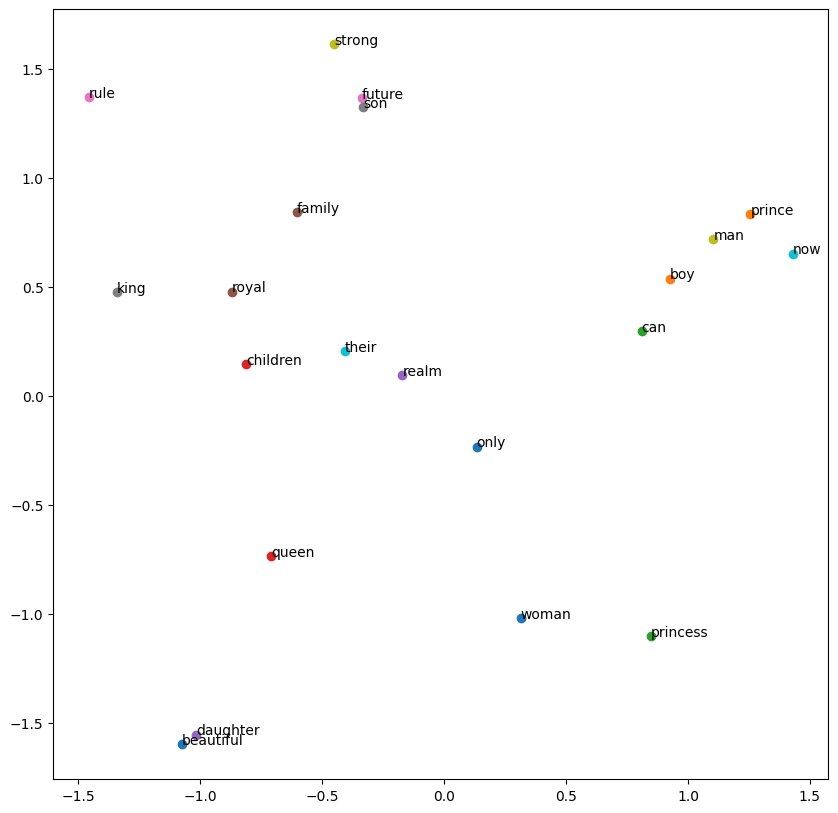

In [29]:
# Ploting the embeddings
plt.figure(figsize=(10, 10))
for word in list(unique_word_dict.keys()):
    coord = embedding_dict.get(word)
    plt.scatter(coord[0], coord[1])
    plt.annotate(word, (coord[0], coord[1]))       


In [30]:
# Saving the embedding vector to a txt file
try:
    os.mkdir(f'{os.getcwd()}/output')        
except Exception as e:
    print(f'Cannot create output folder: {e}')

with open(f'{os.getcwd()}/output/embedding.txt', 'w') as f:
    for key, value in embedding_dict.items():
        try:
            f.write(f'{key}: {value}\n')   
        except Exception as e:
            print(f'Cannot write word {key} to dict: {e}')     

Cannot create output folder: [Errno 17] File exists: '/home/mrx/Documents/Code/Machine_Learning_Universe/Deep_Learning/NLP/word-embedding-creation/output'
